In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../data/traffic_dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (254, 10)


In [4]:
#3 — Select features and target
features = [
    "date",
    "timestamp",
    "direction",
    "day_night",
    "weather",
    "start_frame",
    "number_of_frames"
]

X = df[features].copy()
y = df["traffic_class"]

In [5]:
#4 — Encode categorical features
X = pd.get_dummies(
    X,
    columns=["direction", "day_night", "weather"],
    drop_first=False
)

print("Encoding completed!")
print("Number of features:", X.shape[1])

Encoding completed!
Number of features: 9


In [6]:
#5 — Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 203
Testing samples: 51


In [7]:
#6 — Random Forest before tuning
rf_before = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_before.fit(X_train, y_train)

pred_before = rf_before.predict(X_test)

accuracy_before = accuracy_score(
    y_test,
    pred_before
)

print("Accuracy Before Tuning:",
      round(accuracy_before, 4))

Accuracy Before Tuning: 0.8824


In [8]:
#7 — Define hyperparameters
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

print("Hyperparameters selected for tuning:")
print(param_grid)

Hyperparameters selected for tuning:
{'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]}


In [9]:
#GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Hyperparameter tuning completed!


In [10]:
#9 — Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [11]:
#10 — Best cross-validation accuracy
print("Best Cross-Validation Accuracy:",
      round(grid_search.best_score_, 4))

Best Cross-Validation Accuracy: 0.8772


In [12]:
#11 — Tuned model
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

accuracy_after = accuracy_score(
    y_test,
    tuned_pred
)

print("Accuracy After Tuning:",
      round(accuracy_after, 4))

Accuracy After Tuning: 0.8824


In [13]:
#12 — Before vs After tuning
comparison = pd.DataFrame({
    "Model": [
        "Random Forest Before Tuning",
        "Random Forest After Tuning"
    ],
    "Accuracy": [
        accuracy_before,
        accuracy_after
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

print(comparison)

                         Model  Accuracy
0  Random Forest Before Tuning    0.8824
1   Random Forest After Tuning    0.8824


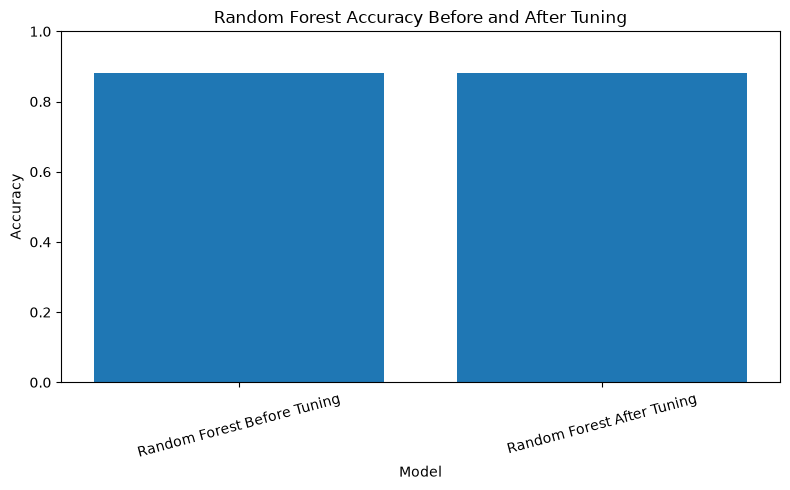

Graph saved to: d:\Traffice-System\outputs\random_forest_tuning_comparison.png


In [14]:
#13 — Save comparison graph
import matplotlib.pyplot as plt
import os

output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Random Forest Accuracy Before and After Tuning")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()

path = os.path.join(
    output_dir,
    "random_forest_tuning_comparison.png"
)

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Graph saved to:", os.path.abspath(path))

In [15]:
#14 — Final tuned model
best_model = grid_search.best_estimator_

print("Final Tuned Random Forest Model:")
print(best_model)

Final Tuned Random Forest Model:
RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)


In [9]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [10]:
df = pd.read_csv("../data/traffic_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (254, 10)


In [11]:
features = [
    "date",
    "timestamp",
    "direction",
    "day_night",
    "weather",
    "start_frame",
    "number_of_frames"
]

X = df[features].copy()
y = df["traffic_class"]

print("X and y created successfully!")

X and y created successfully!


In [12]:
X = pd.get_dummies(
    X,
    columns=["direction", "day_night", "weather"],
    drop_first=False
)

print("Encoding completed!")
print("Number of features:", X.shape[1])

Encoding completed!
Number of features: 9


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 203
Testing samples: 51


In [14]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("GridSearchCV created successfully!")

GridSearchCV created successfully!


In [15]:
grid_search.fit(X_train, y_train)

print("Tuning completed!")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(round(grid_search.best_score_, 4))

Tuning completed!

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best CV Accuracy:
0.8772


In [16]:
best_model = grid_search.best_estimator_

print("Best Model:")
print(best_model)

Best Model:
RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)


In [17]:
import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## Final observation
Random Forest was selected for hyperparameter tuning.
Parameters such as number of trees, maximum depth, and minimum samples split were tested.
GridSearchCV with 5-fold cross-validation was used for tuning.
The best combination of parameters was identified based on cross-validation accuracy.
The resulting best model was saved as best_model.pkl for further evaluation.